In [43]:
# ===== Install (Colab) =====
!pip -q install -U transformers accelerate datasets sentencepiece

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os
import math
import datetime
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import rc
from sklearn.model_selection import train_test_split

# ===== Plotting setup (unchanged) =====
%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = (12, 8)

# ===== Reproducibility =====
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
_ = torch.manual_seed(RANDOM_SEED)

In [46]:
!gdown --id 1OlcvGWReJMuyYQuOZm149vHWwPtlboR6 --output train.csv
!gdown --id 1Oi5cRlTybuIF2Fl5Bfsr-KkqrXrdt77w --output valid.csv
!gdown --id 1ep9H6-HvhB4utJRLVcLzieWNUSG3P_uF --output test.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1OlcvGWReJMuyYQuOZm149vHWwPtlboR6
To: /content/train.csv
100% 799k/799k [00:00<00:00, 28.7MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Oi5cRlTybuIF2Fl5Bfsr-KkqrXrdt77w
To: /content/valid.csv
100% 43.3k/43.3k [00:00<00:00, 64.3MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.goog

In [47]:
train = pd.read_csv("train.csv")
valid = pd.read_csv("valid.csv")
test  = pd.read_csv("test.csv")

display(train.head())
print(len(train), len(valid), len(test))

,text,intent
0,listen to westbam alumb allergic on google music,PlayMusic
1,add step to me to the 50 clásicos playlist,AddToPlaylist
2,i give this current textbook a rating value of...,RateBook
3,play the song little robin redbreast,PlayMusic
4,please add iris dement to my playlist this is ...,AddToPlaylist


13084 700 700


In [48]:
data = pd.read_csv("/content/drive/MyDrive/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

In [49]:
print(len(data))
display(data.head())

26872


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [50]:
import pandas as pd

# If you know the column names you want to extract
desired_columns = ['instruction', 'intent']  # Replace with your actual column names
extracted_data = data[desired_columns].copy()

# OR if you want to extract by column index (position)
# extracted_data = your_dataframe.iloc[:, [0, 2]].copy()  # Replace 0,2 with your desired column indices

print("Available columns:", list(data.columns))
print("Available columns:", list(extracted_data.columns))


Available columns: ['flags', 'instruction', 'category', 'intent', 'response']
Available columns: ['instruction', 'intent']


In [51]:
extracted_data = extracted_data.rename(columns={extracted_data.columns[0]: 'text'})

# extracted_data = extracted_data[[column1, column2]].copy()

# Verify the extracted data
print(f"Extracted data shape: {extracted_data.shape}")
print(f"Unique intents: {extracted_data["intent"].nunique()}")
print(f"Total samples: {len(extracted_data)}")

# from sklearn.model_selection import train_test_split

def stratified_split(df, intent_column, total_samples=24635):
    # Split ratios
    train_ratio = 0.903
    val_ratio = 0.0485
    test_ratio = 0.0485

    # First split: train vs (val + test)
    train_df, temp_df = train_test_split(
        df,
        train_size=train_ratio,
        stratify=df[intent_column],
        random_state=42
    )

    # Adjust val/test ratio relative to temp_df
    val_relative_ratio = val_ratio / (val_ratio + test_ratio)

    # Second split: validation vs test
    val_df, test_df = train_test_split(
        temp_df,
        train_size=val_relative_ratio,
        stratify=temp_df[intent_column],
        random_state=42
    )

    return train_df, val_df, test_df

# Apply the split
train_data, val_data, test_data = stratified_split(extracted_data, "intent")

# Verify the splits
print(f"\nSplit sizes:")
print(f"Train: {len(train_data)} samples")
print(f"Validation: {len(val_data)} samples")
print(f"Test: {len(test_data)} samples")

print(f"\nUnique intents in each split:")
print(f"Train: {train_data["intent"].nunique()} intents")
print(f"Validation: {val_data["intent"].nunique()} intents")
print(f"Test: {test_data["intent"].nunique()} intents")

Extracted data shape: (26872, 2)
Unique intents: 27
Total samples: 26872

Split sizes:
Train: 24265 samples
Validation: 1303 samples
Test: 1304 samples

Unique intents in each split:
Train: 27 intents
Validation: 27 intents
Test: 27 intents


In [52]:
train_data.head()

,text,intent
7170,how do I lodge a damn consumer reclamation?,complaint
21406,i have got to reeport issues with signup,registration_problems
11066,I don't know what I have to do to close my {{A...,delete_account
6613,I want help seeing in what cases can I ask to ...,check_refund_policy
26077,I would like to check the status of my rebate,track_refund


In [53]:
# datasets
splits = {
    "train": (train, train_data),
    "valid": (valid, val_data),
    "test": (test, test_data),
}

# combine them in a loop
combined = {}
for name, (df1, df2) in splits.items():
    combined[name] = pd.concat([df1, df2], ignore_index=True)

# usage
combined_train = combined["train"]
combined_valid = combined["valid"]
combined_test = combined["test"]

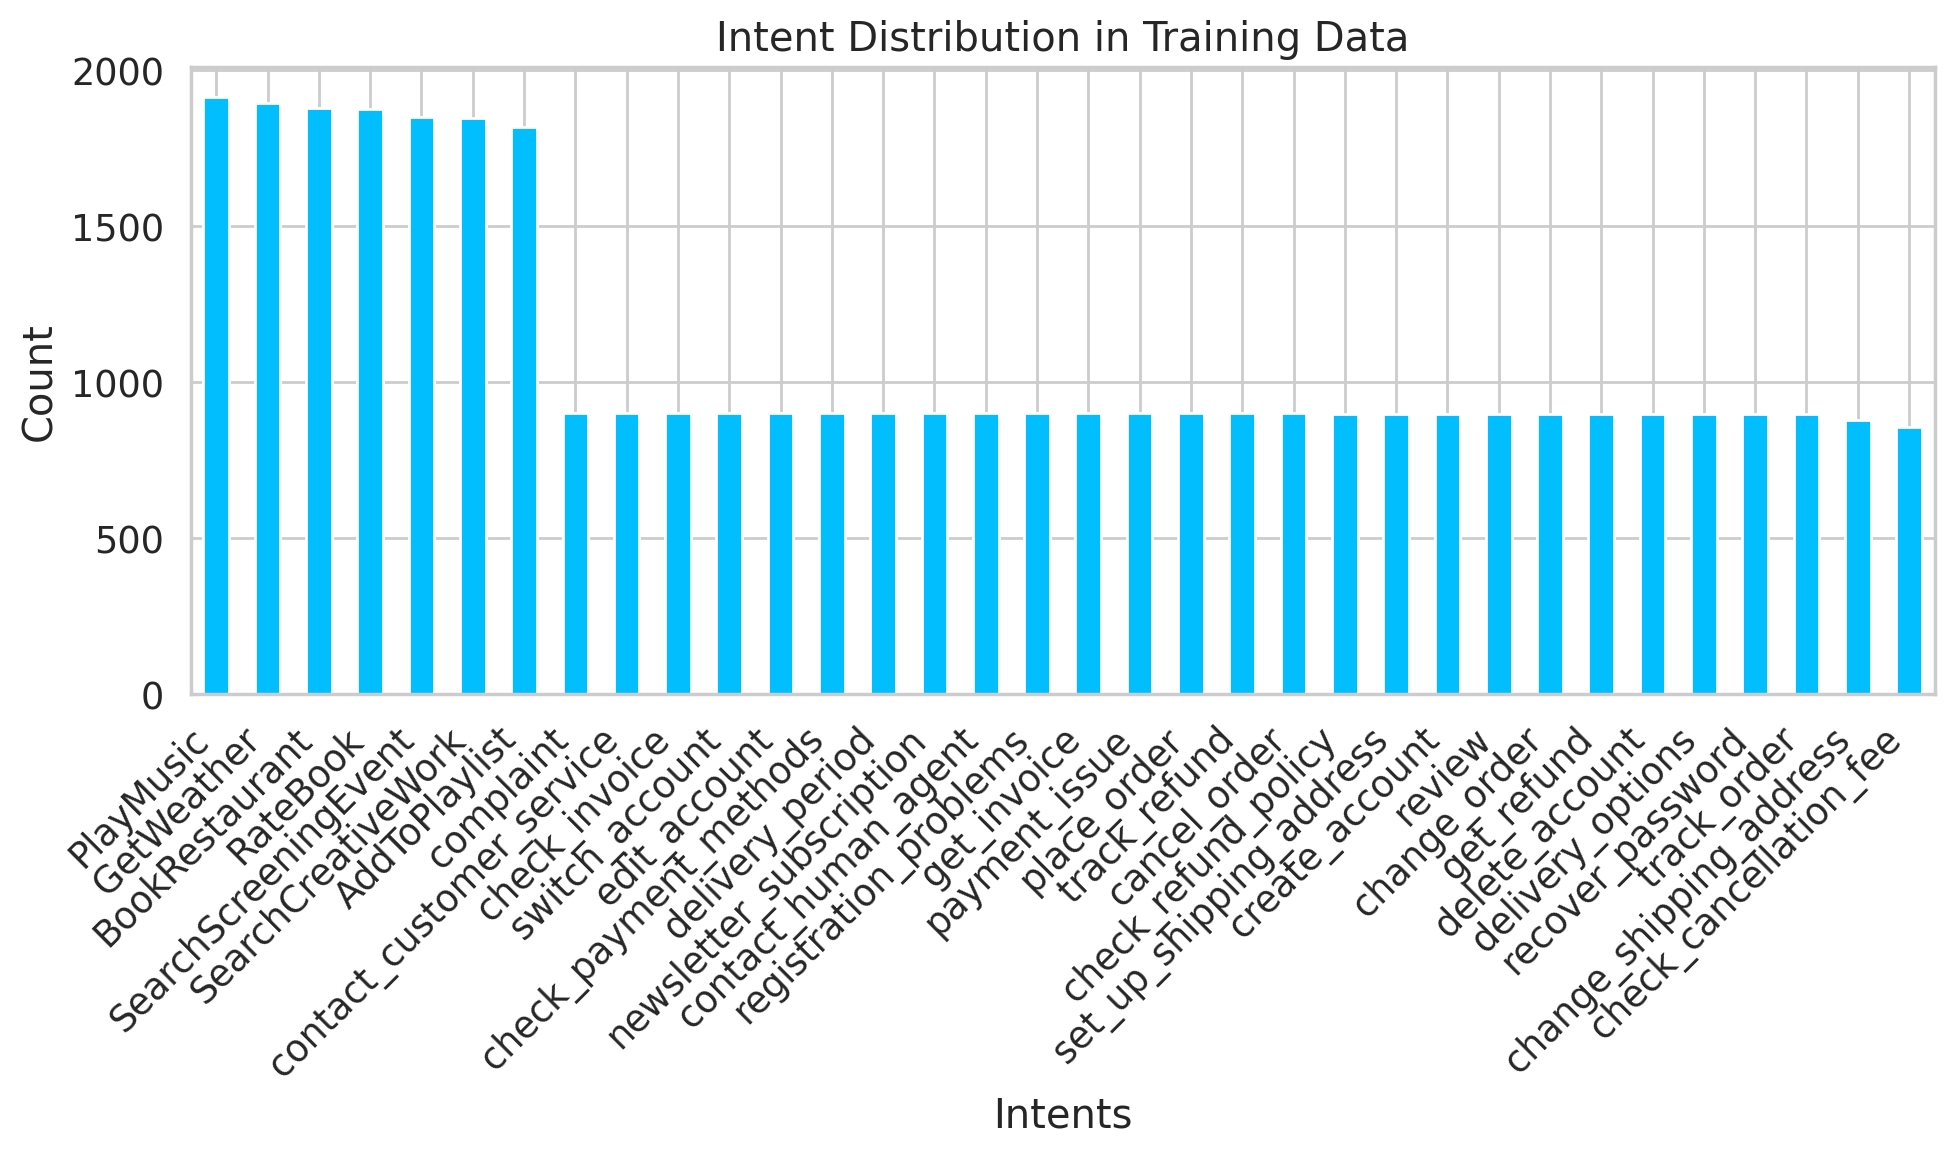

In [54]:
import matplotlib.pyplot as plt

# Example: visualize intents from combined_train
intent_counts = combined_train["intent"].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
intent_counts.plot(kind="bar")

plt.title("Intent Distribution in Training Data")
plt.xlabel("Intents")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [55]:
# ===== Labels mapping =====
labels = sorted(combined_train["intent"].unique().tolist())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(labels)
print("num_labels:", num_labels)

# ===== Tokenizer/Model selection =====
model_name = "bert-base-uncased"  # choose multilingual if needed

tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

num_labels: 34


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [56]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=34
)

print("Model loaded successfully ✅")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully ✅


In [57]:
# ===== Dataset =====
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=64):
        self.texts = df["text"].astype(str).tolist()
        self.labels = [label2id[y] for y in df["intent"].tolist()]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}  # input_ids, attention_mask, token_type_ids (if present)
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ===== DataLoaders =====
max_len = 64
batch_size_train = 32
batch_size_eval  = 64

train_ds = IntentDataset(combined_train, tokenizer, label2id, max_len=max_len)
valid_ds = IntentDataset(combined_valid, tokenizer, label2id, max_len=max_len)
test_ds  = IntentDataset(combined_test,  tokenizer, label2id, max_len=max_len)

train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size_eval, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size_eval,  shuffle=False)


In [58]:
# ===== Device =====
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print("Device:", device)

model.to(device)

# ===== Optimizer & Scheduler =====
from torch.optim import AdamW

epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5)
num_training_steps = epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)


Device: cuda


In [61]:
combined_train.tail()

,text,intent
37344,"I have got to report issues with signup, help me",registration_problems
37345,I try to list your payment methods,check_payment_methods
37346,how do i find the bills from {{Person Name}},check_invoice
37347,i dont know how i can report an issue with signup,registration_problems
37348,how can I inform of a payment error?,payment_issue


In [62]:
# ===== Training loop =====
best_val_acc = 0.0
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)  # returns loss, logits
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [valid]"):
            labels = batch['labels']
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds = logits.argmax(dim=-1).cpu()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total if total > 0 else 0.0
    print(f"Epoch {epoch+1}: train_loss={running_loss/len(train_loader):.4f} val_acc={val_acc:.4f}")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('checkpoint', exist_ok=True)
        model.save_pretrained('checkpoint')
        tokenizer.save_pretrained('checkpoint')
        print("Saved best checkpoint.")


Epoch 1/3 [valid]: 100%|██████████| 32/32 [00:06<00:00,  4.93it/s]


Epoch 1: train_loss=0.6165 val_acc=0.9910
Saved best checkpoint.


Epoch 2/3 [valid]: 100%|██████████| 32/32 [00:06<00:00,  5.00it/s]


Epoch 2: train_loss=0.0420 val_acc=0.9925
Saved best checkpoint.


Epoch 3/3 [valid]: 100%|██████████| 32/32 [00:06<00:00,  4.99it/s]


Epoch 3: train_loss=0.0217 val_acc=0.9930
Saved best checkpoint.


Test: 100%|██████████| 32/32 [00:06<00:00,  4.87it/s]


                          precision    recall  f1-score   support

           AddToPlaylist       1.00      1.00      1.00       124
          BookRestaurant       0.99      1.00      0.99        92
              GetWeather       1.00      0.99      1.00       104
               PlayMusic       0.98      0.98      0.98        86
                RateBook       1.00      1.00      1.00        80
      SearchCreativeWork       0.91      0.98      0.94       107
    SearchScreeningEvent       1.00      0.92      0.96       107
            cancel_order       1.00      1.00      1.00        48
            change_order       1.00      1.00      1.00        48
 change_shipping_address       1.00      1.00      1.00        47
  check_cancellation_fee       1.00      1.00      1.00        46
           check_invoice       1.00      0.98      0.99        49
   check_payment_methods       1.00      1.00      1.00        49
     check_refund_policy       1.00      1.00      1.00        49
         

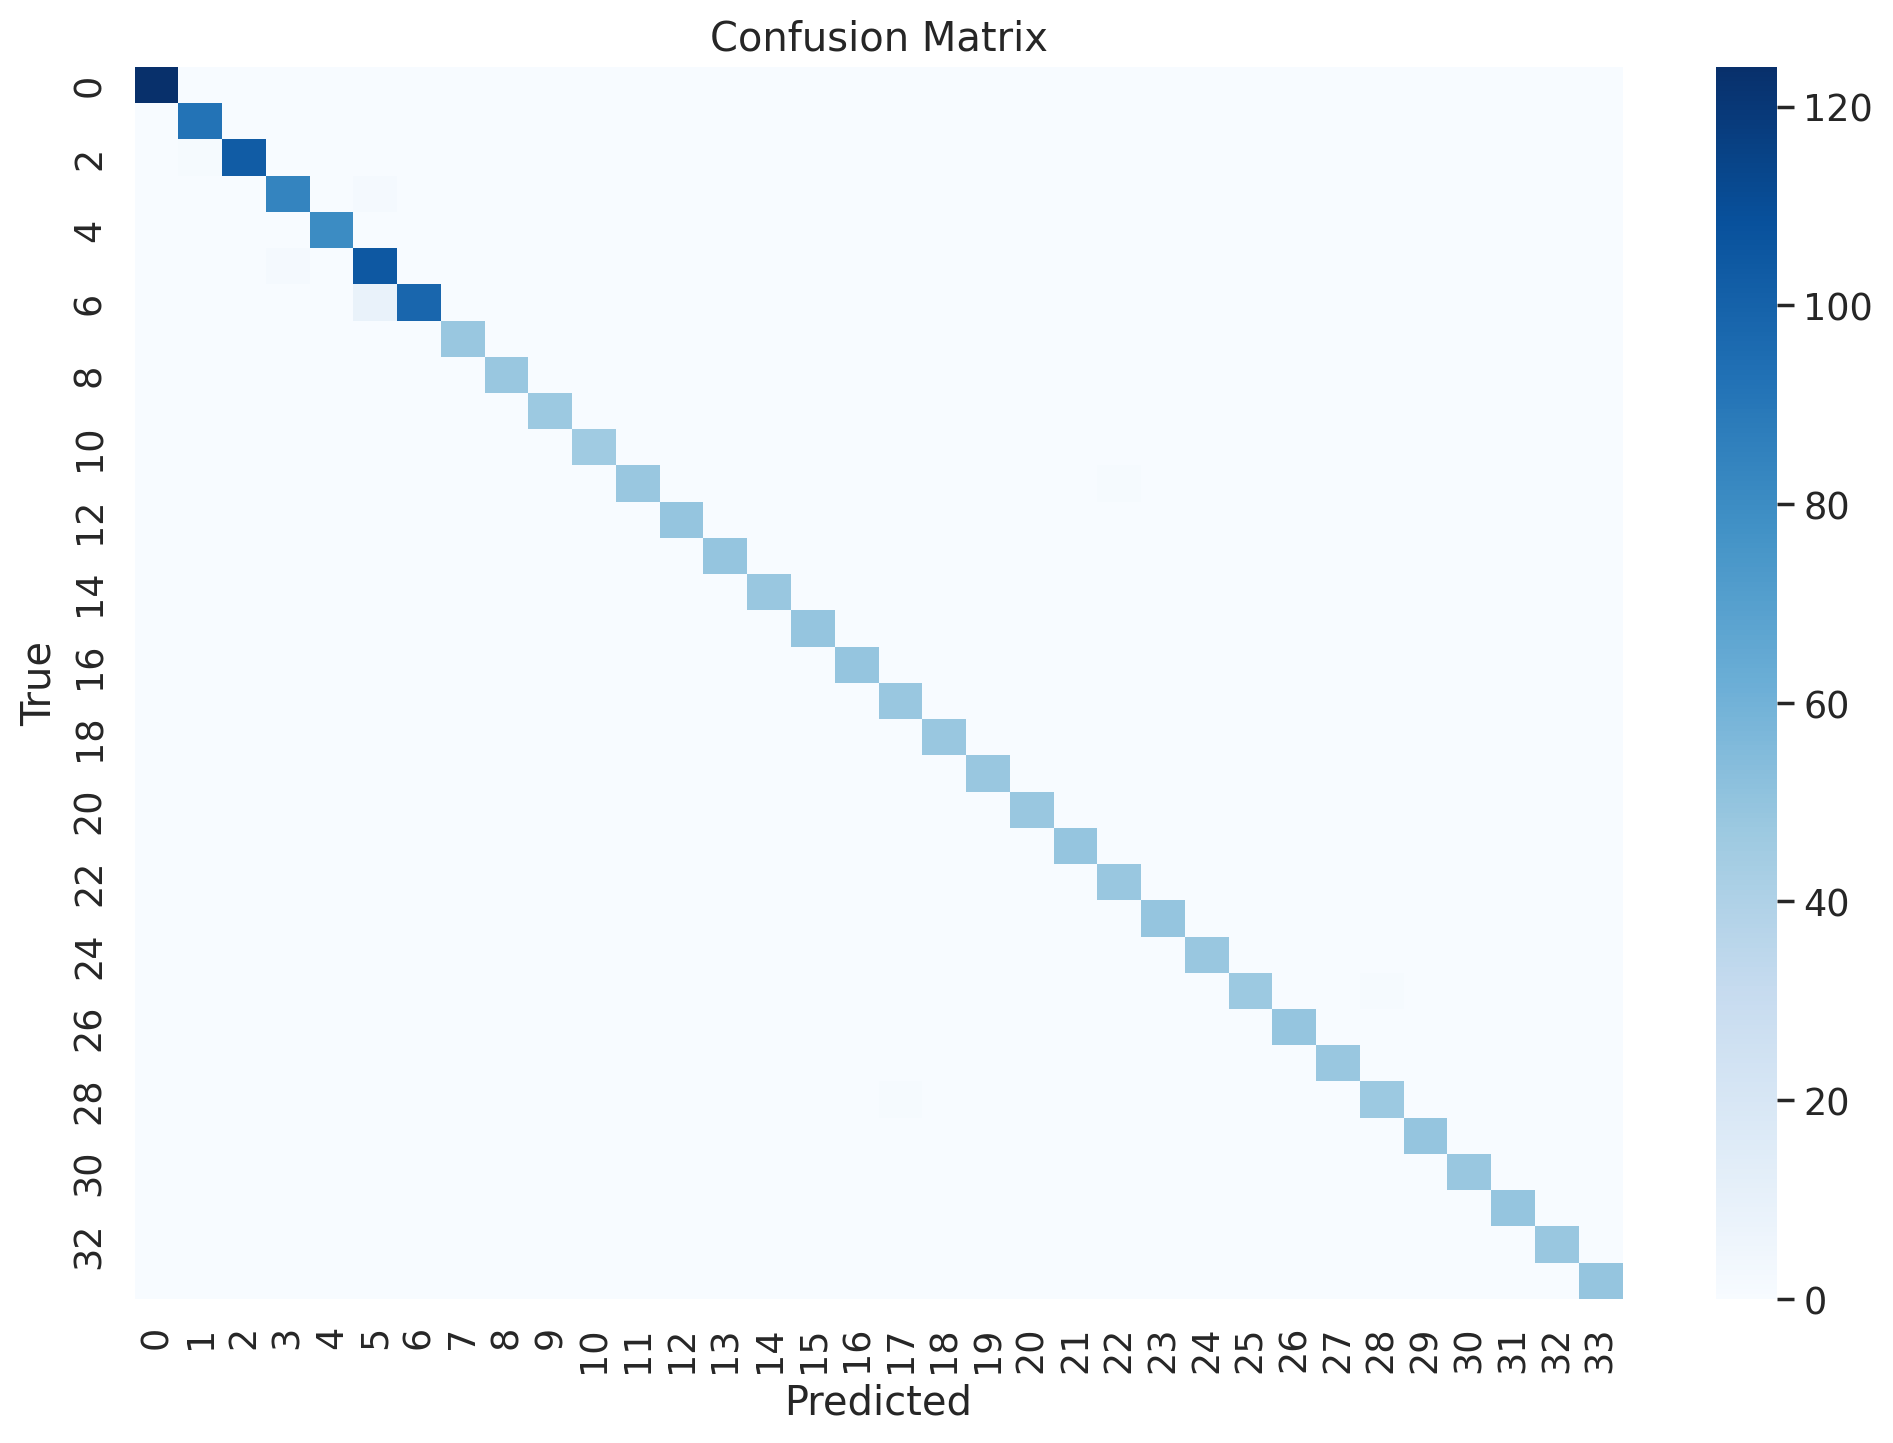

In [63]:
# ===== Load best (optional) =====
model = AutoModelForSequenceClassification.from_pretrained('checkpoint').to(device)

# ===== Test evaluation =====
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        labels = batch['labels']
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

report = classification_report(all_labels, all_preds, target_names=[id2label[i] for i in range(num_labels)])
print(report)
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# ===== Optional: Confusion matrix heatmap =====
plt.figure()
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [64]:
extracted_data.head()

,text,intent
0,question about cancelling order {{Order Number}},cancel_order
1,i have a question about cancelling oorder {{Or...,cancel_order
2,i need help cancelling puchase {{Order Number}},cancel_order
3,I need to cancel purchase {{Order Number}},cancel_order
4,"I cannot afford this order, cancel purchase {{...",cancel_order


In [65]:
# ===== Labels mapping =====
labels = sorted(train_data["intent"].unique().tolist())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(labels)
print("num_labels:", num_labels)

# ===== Tokenizer/Model selection =====
model_name = "bert-base-uncased"  # choose multilingual if needed

tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

num_labels: 27


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


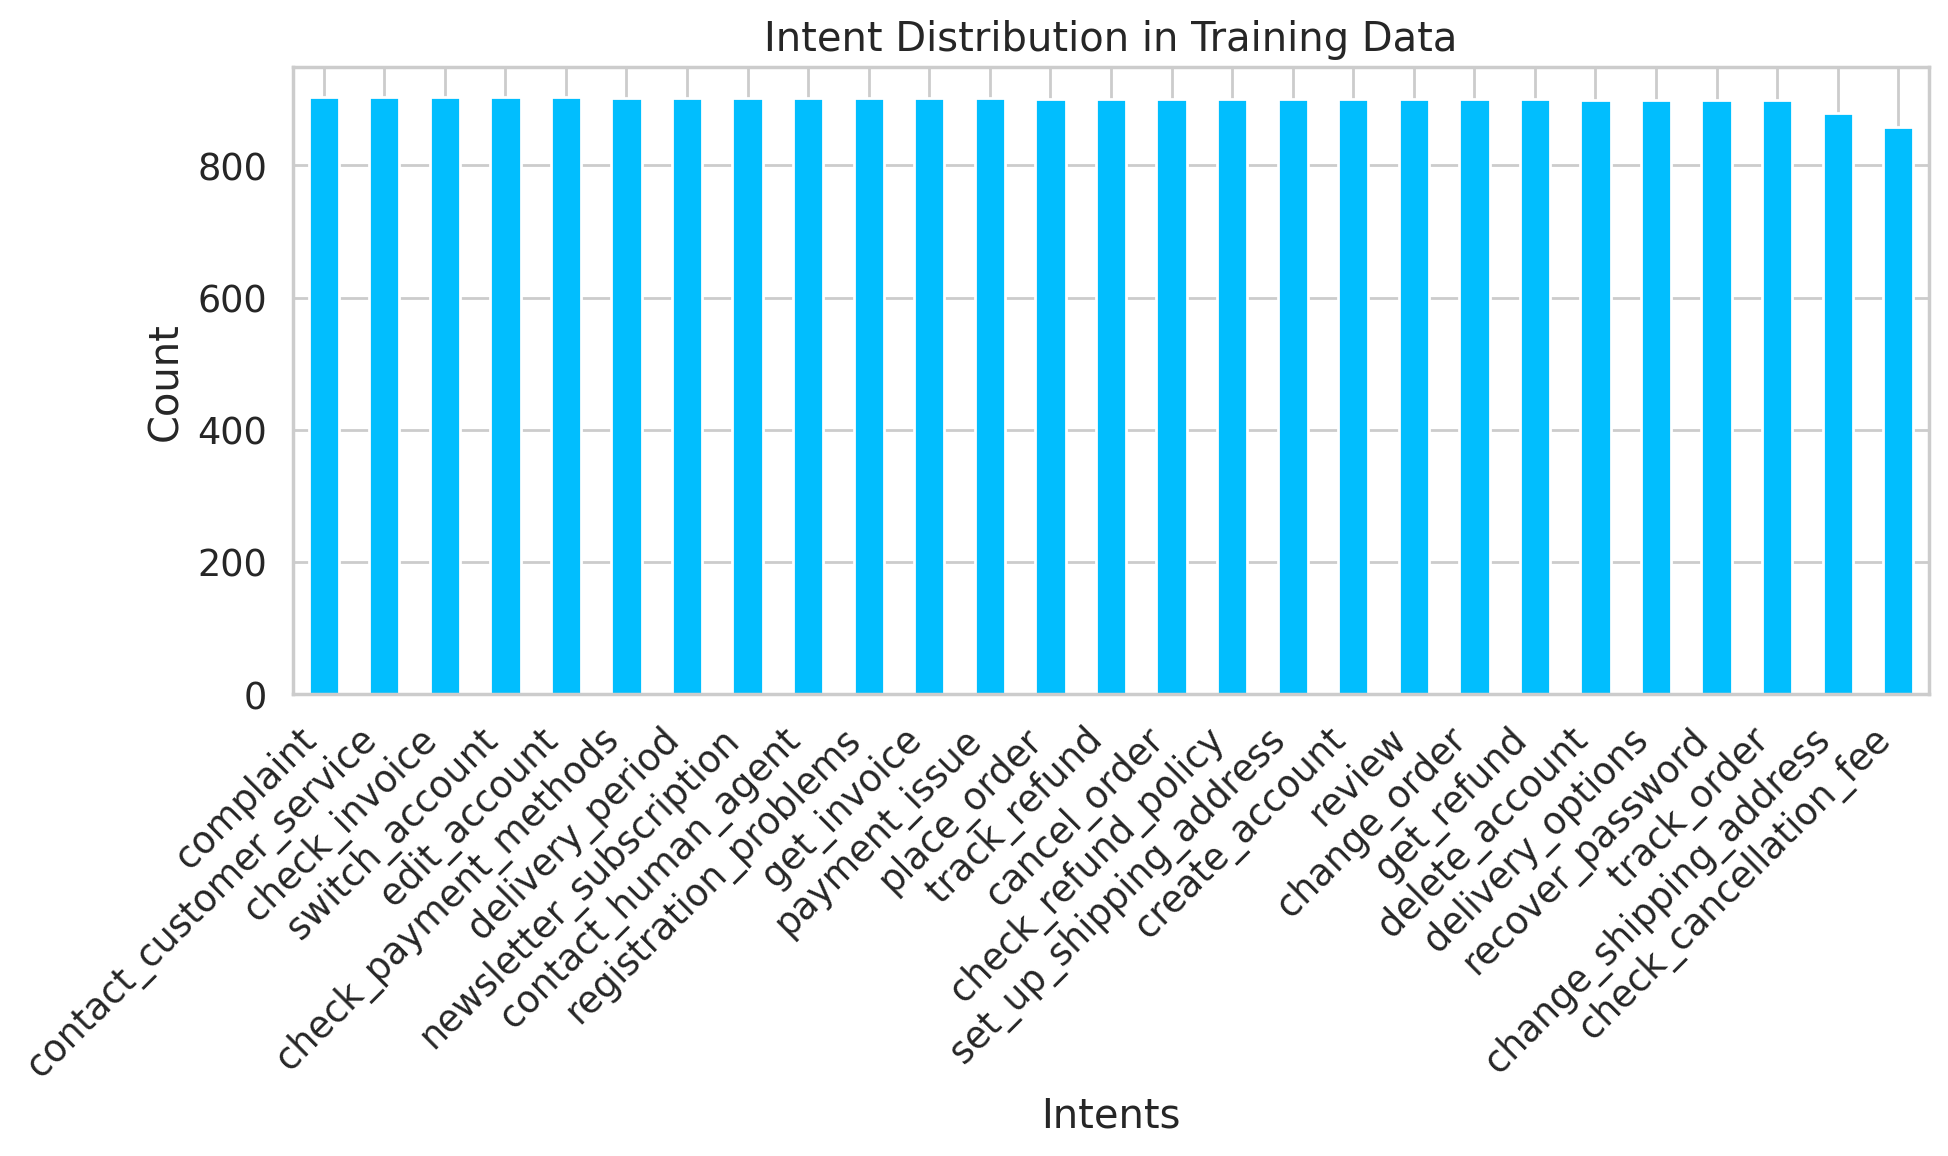

In [66]:
import matplotlib.pyplot as plt

# Example: visualize intents from combined_train
intent_counts = train_data["intent"].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
intent_counts.plot(kind="bar")

plt.title("Intent Distribution in Training Data")
plt.xlabel("Intents")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [67]:
# ===== Labels mapping =====
labels = sorted(train_data["intent"].unique().tolist())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(labels)
print("num_labels:", num_labels)

# ===== Tokenizer/Model selection =====
model_name = "bert-base-uncased"  # choose multilingual if needed

tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

num_labels: 27


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [68]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=34
)

print("Model loaded successfully ✅")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully ✅


In [69]:
# ===== Dataset =====
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=64):
        self.texts = df["text"].astype(str).tolist()
        self.labels = [label2id[y] for y in df["intent"].tolist()]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}  # input_ids, attention_mask, token_type_ids (if present)
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ===== DataLoaders =====
max_len = 64
batch_size_train = 32
batch_size_eval  = 64

train_ds = IntentDataset(train_data, tokenizer, label2id, max_len=max_len)
valid_ds = IntentDataset(val_data, tokenizer, label2id, max_len=max_len)
test_ds  = IntentDataset(test_data,  tokenizer, label2id, max_len=max_len)

train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size_eval, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size_eval,  shuffle=False)


In [70]:
# ===== Device =====
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print("Device:", device)

model.to(device)

# ===== Optimizer & Scheduler =====
from torch.optim import AdamW

epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5)
num_training_steps = epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)


Device: cuda


In [71]:
# ===== Training loop =====
best_val_acc = 0.0
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)  # returns loss, logits
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [valid]"):
            labels = batch['labels']
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds = logits.argmax(dim=-1).cpu()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total if total > 0 else 0.0
    print(f"Epoch {epoch+1}: train_loss={running_loss/len(train_loader):.4f} val_acc={val_acc:.4f}")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('checkpoint', exist_ok=True)
        model.save_pretrained('checkpoint')
        tokenizer.save_pretrained('checkpoint')
        print("Saved best checkpoint.")


Epoch 1/3 [valid]: 100%|██████████| 21/21 [00:04<00:00,  4.94it/s]


Epoch 1: train_loss=1.1712 val_acc=0.9900
Saved best checkpoint.


Epoch 2/3 [valid]: 100%|██████████| 21/21 [00:04<00:00,  4.95it/s]


Epoch 2: train_loss=0.0534 val_acc=0.9946
Saved best checkpoint.


Epoch 3/3 [valid]: 100%|██████████| 21/21 [00:04<00:00,  5.02it/s]


Epoch 3: train_loss=0.0246 val_acc=0.9954
Saved best checkpoint.


Test: 100%|██████████| 21/21 [00:04<00:00,  5.02it/s]


                          precision    recall  f1-score   support

            cancel_order       1.00      1.00      1.00        48
            change_order       1.00      1.00      1.00        48
 change_shipping_address       1.00      1.00      1.00        47
  check_cancellation_fee       1.00      1.00      1.00        46
           check_invoice       0.98      0.98      0.98        49
   check_payment_methods       1.00      1.00      1.00        49
     check_refund_policy       1.00      1.00      1.00        49
               complaint       1.00      1.00      1.00        48
contact_customer_service       1.00      1.00      1.00        49
     contact_human_agent       1.00      1.00      1.00        49
          create_account       0.96      1.00      0.98        48
          delete_account       1.00      1.00      1.00        48
        delivery_options       1.00      1.00      1.00        48
         delivery_period       1.00      1.00      1.00        48
         

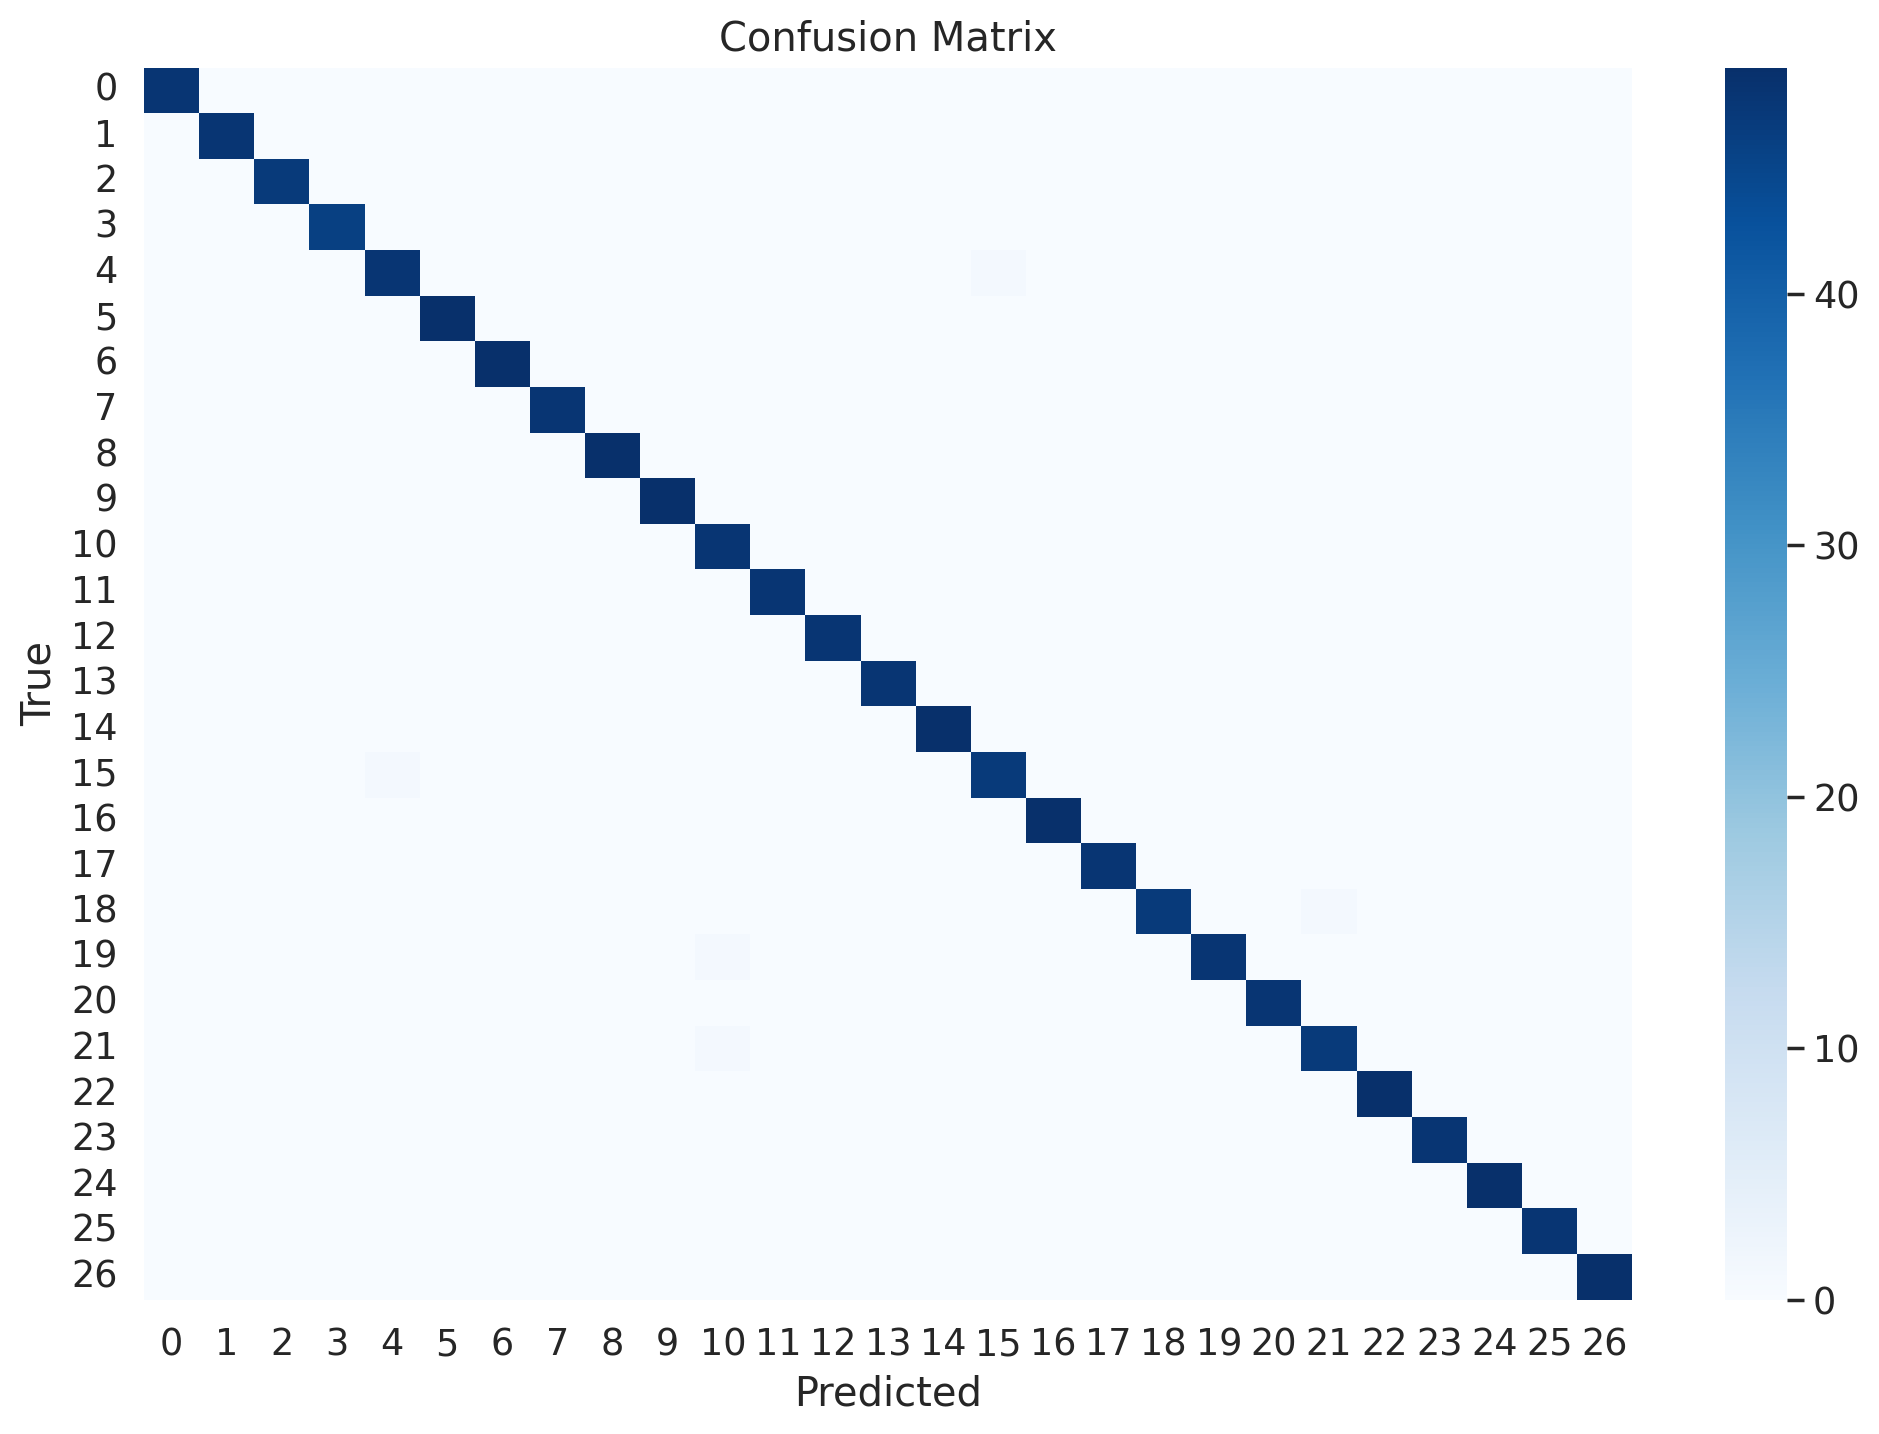

In [72]:
# ===== Load best (optional) =====
model = AutoModelForSequenceClassification.from_pretrained('checkpoint').to(device)

# ===== Test evaluation =====
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        labels = batch['labels']
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

report = classification_report(all_labels, all_preds, target_names=[id2label[i] for i in range(num_labels)])
print(report)
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# ===== Optional: Confusion matrix heatmap =====
plt.figure()
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()